# 01 - Data Import

目标：检查 ClickHouse 连通性、查看日线与因子表行数，并做基础可视化。

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from quant_research.db import query_df

sns.set_theme(style='whitegrid')

In [7]:
query_df('select version() as clickhouse_version')

,clickhouse_version
0,24.8.14.39


In [8]:
query_df('''
select
  (select count() from daily_bars) as bars_rows,
  (select count() from factor_values) as factor_rows
''')

,bars_rows,factor_rows
0,85044,331906


In [9]:
symbol_stats = query_df('''
select symbol, min(trade_date) as start_dt, max(trade_date) as end_dt, count() as n
from daily_bars
group by symbol
order by symbol
''')
symbol_stats

,symbol,start_dt,end_dt,n
0,000001.SZ,2020-01-01,2025-12-31,1566
1,000002.SZ,2020-01-01,2025-12-31,1566
2,300750.SZ,2020-01-01,2025-12-31,1566
3,600000.SH,2020-01-01,2025-12-31,1566
4,600519.SH,2020-01-01,2025-12-31,1566
...,...,...,...,...
100,US:TXN,2020-01-02,2026-03-18,1560
101,US:UNH,2026-02-17,2026-03-18,22
102,US:V,2026-02-17,2026-03-18,22
103,US:WMT,2026-02-17,2026-03-18,22


In [10]:
bars = query_df('''
select trade_date, symbol, close, volume, ret_1d, ret_5d
from daily_bars
order by trade_date, symbol
''')
bars['trade_date'] = pd.to_datetime(bars['trade_date'])
bars.head()

,trade_date,symbol,close,volume,ret_1d,ret_5d
0,2020-01-01,000001.SZ,100.639434,1.221349e+06,0.0,0.0
1,2020-01-01,000002.SZ,104.168742,1.381827e+06,0.0,0.0
2,2020-01-01,300750.SZ,100.821407,8.858298e+05,0.0,0.0
3,2020-01-01,600000.SH,101.834368,1.192333e+06,0.0,0.0
4,2020-01-01,600519.SH,97.424174,9.071331e+05,0.0,0.0


## 可视化 1: 每个股票的数据量

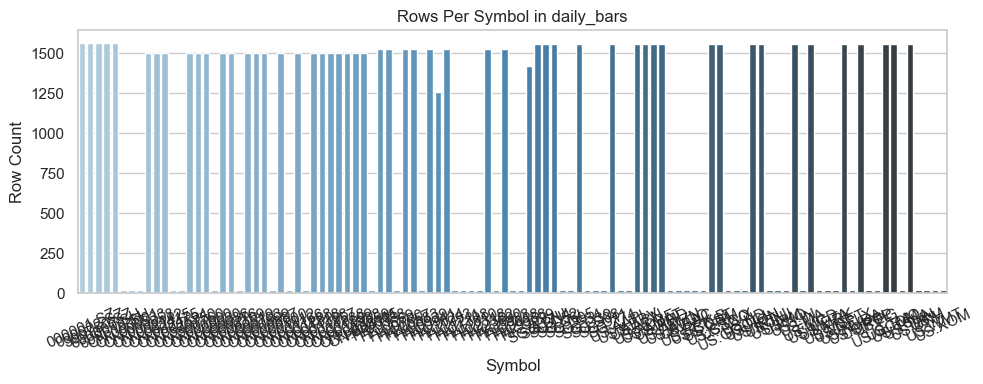

In [11]:
plt.figure(figsize=(10, 4))
sns.barplot(data=symbol_stats, x='symbol', y='n', hue='symbol', palette='Blues_d', legend=False)
plt.title('Rows Per Symbol in daily_bars')
plt.xlabel('Symbol')
plt.ylabel('Row Count')
plt.xticks(rotation=25)
plt.tight_layout()

## 可视化 2: 每个交易日记录数

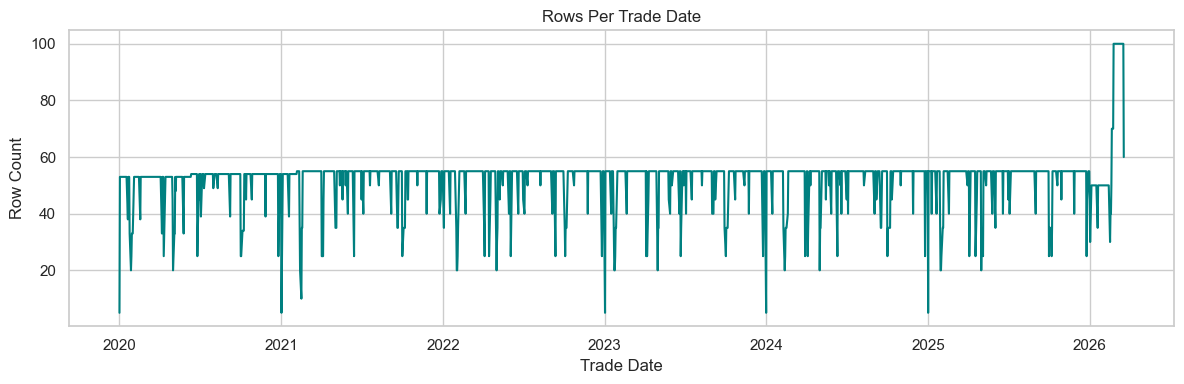

In [12]:
daily_counts = bars.groupby('trade_date', as_index=False).size().rename(columns={'size': 'n_rows'})
plt.figure(figsize=(12, 4))
sns.lineplot(data=daily_counts, x='trade_date', y='n_rows', color='teal')
plt.title('Rows Per Trade Date')
plt.xlabel('Trade Date')
plt.ylabel('Row Count')
plt.tight_layout()

## 可视化 3: 日收益分布

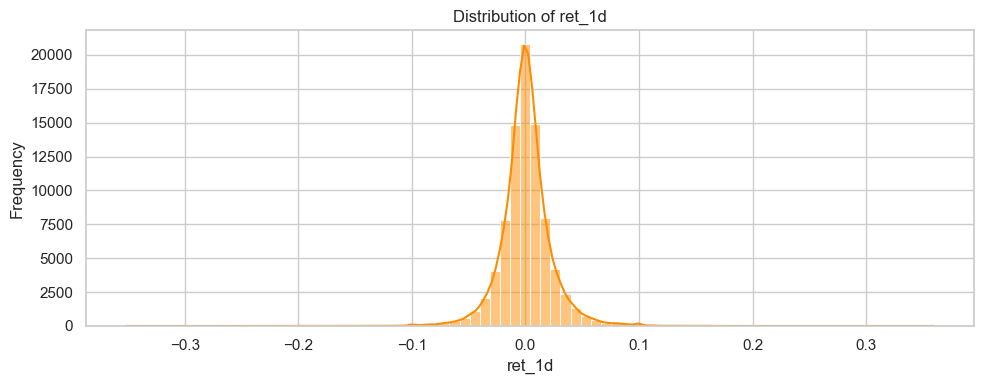

In [13]:
plt.figure(figsize=(10, 4))
sns.histplot(bars['ret_1d'], bins=80, kde=True, color='darkorange')
plt.title('Distribution of ret_1d')
plt.xlabel('ret_1d')
plt.ylabel('Frequency')
plt.tight_layout()